<a href="https://colab.research.google.com/github/bhanu151/statistical-learning-course-2026/blob/main/CSSL11_k_means_and_hierarchical_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
iris = datasets.load_iris()
X_raw = iris.data

1. Scale features, if necessary.
2. Extract only 2 features - petal length and petal width into X.
3. Perform K means clustering
4. Scatter the points clustered into different classes onto the feature space. Use different colors to represent different classes.
4. Try different values of K. Plot an elbow plot showing the within cluster sum of squared distances (interia) against K. Identify where the elbow bends
5. Try agglomerative clustering on X, with just the same two features.
6. Scatter the points clustered into different classes onto the feature space. Use different colors to represent different classes. Also visualize the dendrogram.
7. Repeat steps 5 and 6 using different linkage methods-single, complete, average.


In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X = X_scaled[:,2:4]

# K-means

Text(0, 0.5, 'Scaled petal width')

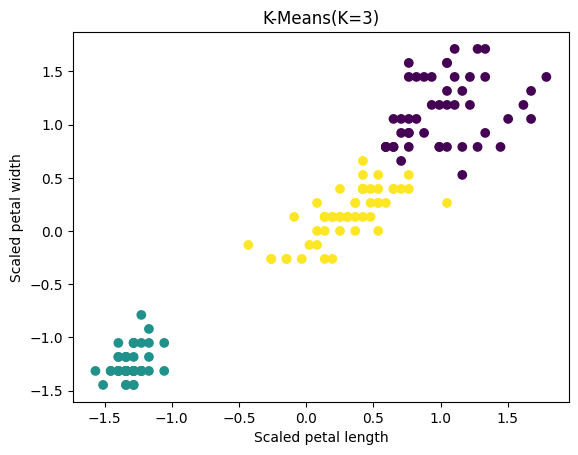

In [21]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=100)
y_kmeans = kmeans.fit_predict(X)

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans)
plt.title("K-Means(K=3)")
plt.xlabel("Scaled petal length")
plt.ylabel("Scaled petal width")

## Elbow plot

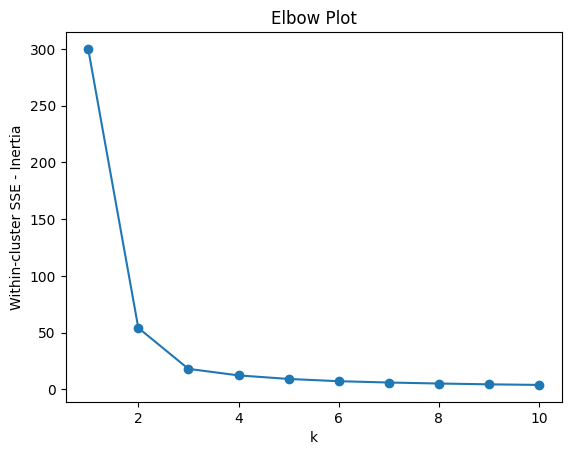

In [22]:
inertia_values = []
k_values = range(1, 11)
for k in k_values:
  km = KMeans(n_clusters=k, random_state=42, n_init=100)
  km.fit(X)
  inertia_values.append(km.inertia_)

plt.plot(k_values, inertia_values, marker="o", ls="-")
plt.xlabel("k")
plt.ylabel("Within-cluster SSE - Inertia")
plt.title("Elbow Plot")
plt.show()

Elbow seems to appear at k=3. This seems to match the natural number of classes present in the iris dataset. However, at this point we do not know whether the classes obtained from k means clustering actually match the natural classes for each and every datapoint. That will require further investigation.

Here, one could have also chosen k=2, since the decrease in variance when you go from k=2 to k=3 isn't very high. But from eyeballing, one can see tha k=2 or k=3 would be natural choices as the elbow bends there.

# Agglomerative (Hierarchical) Clustering

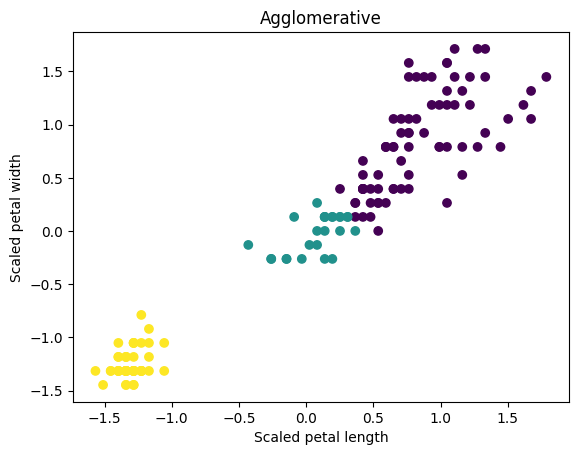

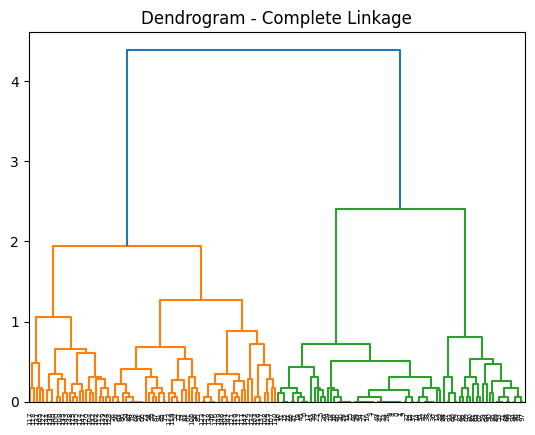

In [24]:
agg_model = AgglomerativeClustering(n_clusters=3, linkage="complete") # The default linkage is ward linkage.
# Note: Instead of specifying the number of clusters here, we can also specify the distance at which the dendrogram can be cut using the distance_threshold parameter
y_agg = agg_model.fit_predict(X)

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y_agg)
plt.title("Agglomerative")
plt.xlabel("Scaled petal length")
plt.ylabel("Scaled petal width")

plt.figure()
linkage_matrix = linkage(X, "complete")
dendrogram(linkage_matrix)
plt.title("Dendrogram - Complete Linkage")
plt.show()

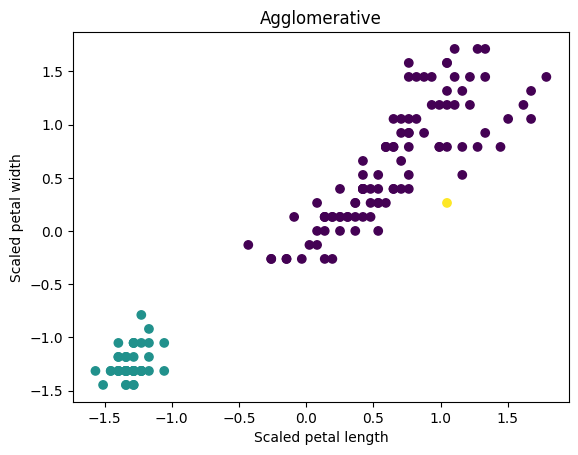

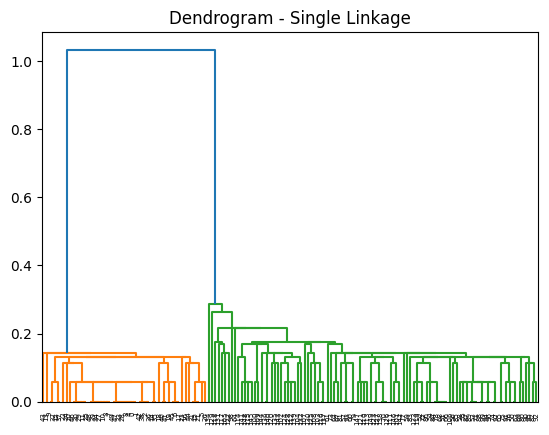

In [25]:
agg_model = AgglomerativeClustering(n_clusters=3, linkage="single") # The default linkage is ward linkage
y_agg = agg_model.fit_predict(X)

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y_agg)
plt.title("Agglomerative")
plt.xlabel("Scaled petal length")
plt.ylabel("Scaled petal width")

plt.figure()
linkage_matrix = linkage(X, "single")
dendrogram(linkage_matrix)
plt.title("Dendrogram - Single Linkage")
plt.show()

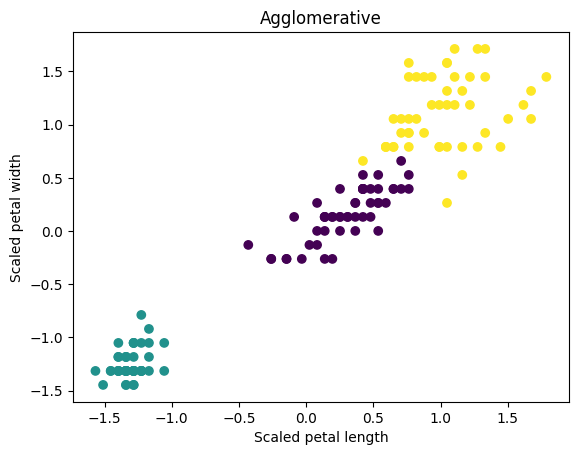

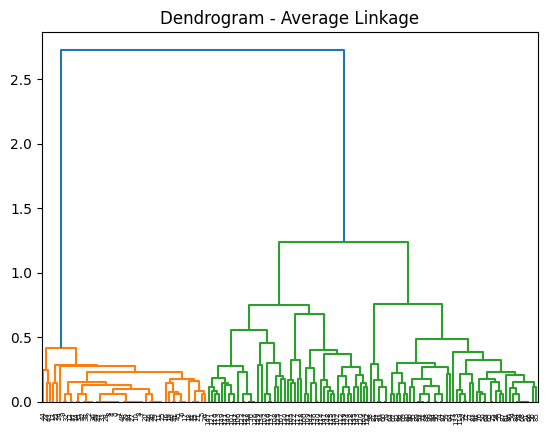

In [28]:
agg_model = AgglomerativeClustering(n_clusters=3, linkage="average") # The default linkage is ward linkage
y_agg = agg_model.fit_predict(X)

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y_agg)
plt.title("Agglomerative")
plt.xlabel("Scaled petal length")
plt.ylabel("Scaled petal width")

plt.figure()
linkage_matrix = linkage(X, "average")
dendrogram(linkage_matrix)
plt.title("Dendrogram - Average Linkage")
plt.show()

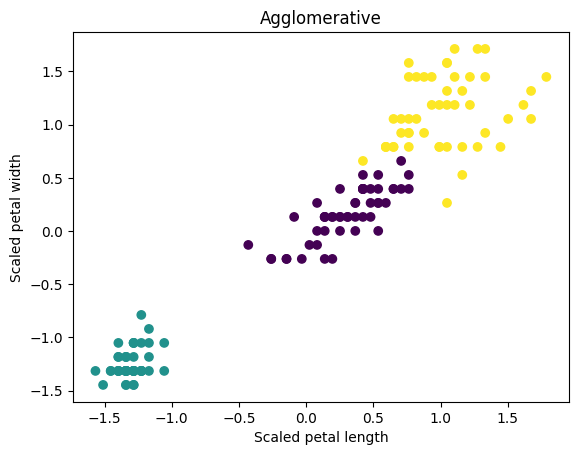

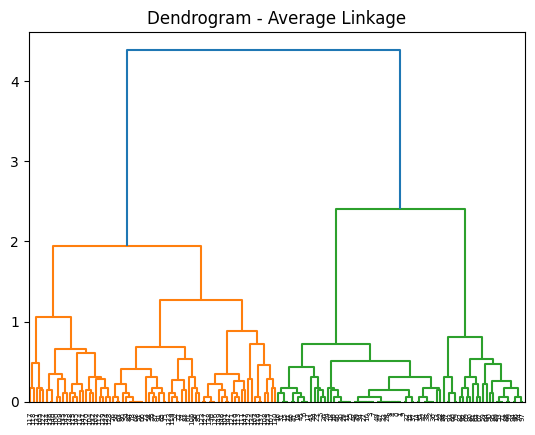

In [ ]:
agg_model = AgglomerativeClustering(n_clusters=3, linkage="ward") # The default linkage is ward linkage which focuses on minimizing the increase in within cluster variance
y_agg = agg_model.fit_predict(X)

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y_agg)
plt.title("Agglomerative")
plt.xlabel("Scaled petal length")
plt.ylabel("Scaled petal width")

plt.figure()
linkage_matrix = linkage(X, "ward")
dendrogram(linkage_matrix)
plt.title("Dendrogram - Ward Linkage")
plt.show()

Notice how the clusters appear more balanced with average, ward and complete linkage. However, single linkage shows more signs of chaining where new datapoints keep getting merged into existing clusters. For more details on how different linkage methods operate on different types of datasets, refer to [this link](https://scikit-learn.org/stable/auto_examples/cluster/plot_linkage_comparison.html#sphx-glr-auto-examples-cluster-plot-linkage-comparison-py).

**Note: Instead of specifying the number of clusters here, we can also specify the distance at which the dendrogram can be cut using the distance_threshold parameter**